In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans Mono'
from data import load_data

df = load_data()
fd = df.transpose().iloc[3:]

base_freq = np.zeros((df.shape[1]-3, 4))
for num_order, (name, col) in enumerate(df.iloc[:, 3:].items()):
    base_freq[num_order, 0] = col.str.count('A').sum()
    base_freq[num_order, 1] = col.str.count('C').sum()
    base_freq[num_order, 2] = col.str.count('G').sum()
    base_freq[num_order, 3] = col.str.count('T').sum()
base_freq_rel = base_freq / np.sum(base_freq, axis=1, keepdims=True)

mask_AC = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [0, 1], axis=1)
mask_CA = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [1, 0], axis=1)
mask_AG = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [0, 2], axis=1)
mask_GA = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [2, 0], axis=1)
mask_CT = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [1, 3], axis=1)
mask_TC = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [3, 1], axis=1)
mask_GT = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [2, 3], axis=1)
mask_TG = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [3, 2], axis=1)

mask_AC_CA = mask_AC | mask_CA
mask_AG_GA = mask_AG | mask_GA
mask_CT_TC = mask_CT | mask_TC
mask_GT_TG = mask_GT | mask_TG

dist_f = np.zeros((fd.shape[0], fd.shape[0]))
for i, j in np.ndindex(dist_f.shape):
    dist_f[i, j] = (fd.iloc[i] != fd.iloc[j]).sum()
    dist_f[j, i] = dist_f[i, j]


In [246]:
X_str = df.iloc[:, 3:].values
y = df['Geographic region'].values

In [282]:
from gtda.homology import VietorisRipsPersistence
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def run_experiment_once(
    X, y, train_idxs, col_pers, col_drop, model, metric='hamming'
):
    def _extract_persistence_from_data(arr):
        pers_hom = VietorisRipsPersistence(
            metric=metric,
        )
        # arr = OneHotEncoder(sparse=False).fit_transform(arr.T)
        pers = pers_hom.fit_transform(arr.T[np.newaxis])
        pers = pers[pers[..., 2] == 1]
        pers = pers[np.argmax(pers[:, 1] - pers[:, 0]), :2]
        return pers
    
    # splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # for train_idxs, test_idxs in splitter.split(X, y):
    X_train, y_train = X[train_idxs], y[train_idxs]
    X_test, y_test = np.delete(X, train_idxs, axis=0), np.delete(y, train_idxs, axis=0)

    pers_full_control = _extract_persistence_from_data(X[:, col_pers])
    pers_full_modified = _extract_persistence_from_data(X[:, col_pers & (~col_drop)])
    pers_train_control = _extract_persistence_from_data(X_train[:, col_pers])
    pers_train_modified = _extract_persistence_from_data(X_train[:, col_pers & (~col_drop)])
    
    model.fit(X_train, y_train)
    score_control = accuracy_score(y_test, model.predict(X_test))*1e2

    if hasattr(model, 'min_categories'):
        min_categories = model.min_categories[:]
        model.set_params(min_categories=model.min_categories[~col_drop])
    model.fit(X_train[:, ~col_drop], y_train)
    score_modified = accuracy_score(y_test, model.predict(X_test[:, ~col_drop]))*1e2
    if hasattr(model, 'min_categories'):
        model.set_params(min_categories=min_categories)

    return np.concatenate([
        pers_full_control, pers_full_modified,
        pers_train_control, pers_train_modified,
        [score_control, score_modified]
    ], axis=0)
col_names = [
    'birth_full_control', 'death_full_control', 'birth_full_modified', 'death_full_modified',
    'birth_train_control', 'death_train_control', 'birth_train_modified', 'death_train_modified',
    'score_control', 'score_modified',
]

In [285]:
X_oe = OrdinalEncoder().fit_transform(X_str)
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

n_drop = 20
n_iter = 100
rng = np.random.default_rng(42)
col_pers = mask_AG_GA
exp_results = []
for num in range(n_iter):
    col_drop = np.full_like(col_pers, False)
    col_drop[rng.choice(np.where(col_pers)[0], size=n_drop, replace=False)] = True

    # model = make_pipeline(
    #     OneHotEncoder(
    #         handle_unknown='ignore'
    #     ),
    #     LogisticRegression(
    #         max_iter=1000,
    #         random_state=42
    #     )
    # )
    model = CategoricalNB(
        min_categories=df.iloc[:, 3:].nunique().values
    )

    for train_idxs, test_idxs in splitter.split(X_oe, y):
        exp_result =  run_experiment_once(
            X_oe, y, train_idxs, col_pers, col_drop, model, metric='hamming'
        )
        exp_results.append(exp_result)
exp_results = pd.DataFrame(
    exp_results, 
    index=np.arange(5*n_iter)//5,
    columns=col_names
)

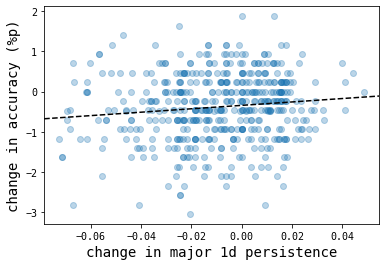

In [303]:
import statsmodels.api as sm

score = exp_results['score_modified']
score_change = exp_results['score_modified'] - exp_results['score_control']
lifetime_full_control = exp_results['death_full_control'] - exp_results['birth_full_control']
lifetime_train_control = exp_results['death_train_control'] - exp_results['birth_train_control']
lifetime_full_modified = exp_results['death_full_modified'] - exp_results['birth_full_modified']
lifetime_train_modified = exp_results['death_train_modified'] - exp_results['birth_train_modified']

reg_x = lifetime_train_modified - lifetime_train_control
reg_y = score_change

reg_result = sm.OLS(reg_y, sm.add_constant(reg_x)).fit()
intercept, coef = reg_result.params
plt.scatter(reg_x, reg_y, alpha=0.3)
x0, x1 = plt.xlim(auto=False); plt.ylim(auto=False)
plt.plot([x0, x1], [intercept+coef*x0, intercept+coef*x1], 'k--')
plt.xlabel('change in major 1d persistence', fontsize=14)
plt.ylabel('change in accuracy (%p)', fontsize=14)
plt.show(); plt.close()

# What can be done next?
- permutation of bases

- change number of features deleted

- change model

- change metric

- extract other homological invariant

In [173]:
import itertools

foo = np.zeros((24, fd.shape[0], fd.shape[1]))
for num_order, order in enumerate(itertools.permutations('ACGT')):
    for num_row, (_, row) in enumerate(fd.iterrows()):
        for base in 'ACGT':
            foo[num_order, num_row] += row.str.count(base) * (3**order.index(base))

array([[54., 30., 30., ..., 30., 30., 54.],
       [18., 18., 10., ..., 18., 18., 10.],
       [10., 18., 18., ...,  2.,  2.,  2.],
       ...,
       [ 6., 30., 30., ...,  6., 30., 54.],
       [ 2.,  2.,  2., ..., 10., 10., 10.],
       [30., 30., 30., ...,  6., 30., 30.]])